# CareerMatch – Top-3 Career Role Recommendation Using KNN

This notebook contains the final mini-project workflow using the original 1,500-row dataset.

CareerMatch is treated as a **career recommendation system** rather than a single exact-career classifier.  
For each student profile, the model returns the **Top 3 recommended career roles** using K-Nearest Neighbors (KNN).

The main evaluation metric used in this notebook is **Top-3 Recommendation Coverage**:
> A prediction is counted as correct when the actual career appears anywhere among the three recommended careers.


## 1. Dataset Loading and Initial Exploration


In [1]:
import pandas as pd

df = pd.read_csv("../data/perfectly_realistic_career_guidance_dataset_1500.csv")

df.head()

,Education_Level,Specialization,Skills,Interests,Recommended_Career,Career_Description
0,B.Com,Finance,"Communication, Tax Filing",Social Work,Financial Analyst,B.Com graduates specialized in Finance with sk...
1,MBA,Marketing,"Leadership, Strategy, Analytics",Management,HR Specialist,MBA graduates specialized in Marketing with sk...
2,BCA,Computer Applications,"Python, Web Development, Databases",Social Work,System Analyst,BCA graduates specialized in Computer Applicat...
3,BA,Political Science,"Writing, Communication",Research,Journalist,BA graduates specialized in Political Science ...
4,BCA,Computer Applications,"Python, Web Development, Databases",Technology,System Analyst,BCA graduates specialized in Computer Applicat...


In [2]:
df.shape

(1500, 6)

In [3]:
df.columns

Index(['Education_Level', 'Specialization', 'Skills', 'Interests',
       'Recommended_Career', 'Career_Description'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Education_Level     1500 non-null   object
 1   Specialization      1500 non-null   object
 2   Skills              1500 non-null   object
 3   Interests           1500 non-null   object
 4   Recommended_Career  1500 non-null   object
 5   Career_Description  1500 non-null   object
dtypes: object(6)
memory usage: 70.4+ KB


In [5]:
df.isnull().sum()

Education_Level       0
Specialization        0
Skills                0
Interests             0
Recommended_Career    0
Career_Description    0
dtype: int64

In [6]:
df["Recommended_Career"].value_counts()

Recommended_Career
Lecturer                      81
Teacher                       57
Auditor                       54
AI Engineer                   50
Research Scientist            40
General Practitioner          39
Data Analyst                  35
Lab Technician                33
Financial Analyst             33
Editor                        33
Clerk                         32
School Coordinator            32
Finance Manager               31
Junior Assistant              29
Doctor                        29
Sales Assistant               29
Technician                    28
Software Architect            28
Tutor                         27
Analyst                       27
AutoCAD Designer              27
Business Analyst              27
Data Scientist                26
Data Entry Operator           26
Fashion Designer              25
Graphic Designer              25
Marketing Executive           25
Professor                     25
Content Writer                24
Accountant              

In [7]:
df.nunique()

Education_Level         20
Specialization          37
Skills                  49
Interests               10
Recommended_Career      55
Career_Description    1207
dtype: int64

In [8]:
X = df[
    [
        "Education_Level",
        "Specialization",
        "Skills",
        "Interests"
    ]
]

y = df["Recommended_Career"]

print("Input shape:", X.shape)
print("Target shape:", y.shape)

Input shape: (1500, 4)
Target shape: (1500,)


In [9]:
for col in ["Education_Level", "Specialization", "Interests"]:
    print(f"\n{col}:")
    print(df[col].unique())


Education_Level:
['B.Com' 'MBA' 'BCA' 'BA' 'PhD' 'B.Ed' 'B.Des' 'MA' '10th' 'M.Tech'
 'M.Com' 'BBA' 'M.Sc' 'MBBS' '12th' 'MCA' 'M.Ed' 'B.Sc' 'Diploma' 'B.Tech']

Specialization:
['Finance' 'Marketing' 'Computer Applications' 'Political Science'
 'Social Science' 'Mathematics' 'Animation' 'English' 'History' 'Commerce'
 'Computer Science' 'Operations' 'Management' 'Sociology' 'Taxation' 'HR'
 'Biology' 'Medicine' 'Education' 'Information Systems'
 'Structural Engineering' 'Physics' 'Humanities' 'Administration'
 'Science' 'Mechanical' 'Accounting' 'Chemistry' 'General Studies'
 'Electrical' 'Civil' 'Electronics' 'Graphic Design' 'Fashion' 'Banking'
 'Power Systems' 'Engineering']

Interests:
['Social Work' 'Management' 'Research' 'Technology' 'Healthcare'
 'Teaching' 'Business' 'Creativity' 'Design' 'Helping People']


In [10]:
print(df["Skills"].unique())

['Communication, Tax Filing' 'Leadership, Strategy, Analytics'
 'Python, Web Development, Databases' 'Writing, Communication'
 'Research, Data Analysis, Publication' 'Student Mentoring'
 'Sketching, Visualization' 'Research, Public Speaking'
 'Content Writing, Research' 'Customer Service, Teamwork'
 'AI, Simulation, MATLAB' 'Teaching, Communication' 'Advanced Excel, GST'
 'Team Management, Excel' 'Tax Management' 'Planning, Communication'
 'Analysis, Experimentation' 'Diagnosis, Surgery, Patient Care'
 'Communication' 'Excel, Communication' 'Teaching, Curriculum Design'
 'Programming, AI, Cloud' 'Typing, Customer Handling'
 'Power Analysis, Python' 'Research, Data Collection'
 'Data Entry, Business Analytics' 'Basic Accounting, Data Entry'
 'Assessment Design' 'Typing, Office Work'
 'Data Analysis, Experimentation' 'Critical Thinking'
 'Electrical Wiring, CAD' 'Budgeting, Reporting'
 'Maintenance, Troubleshooting' 'Database Design, Python'
 'Basic Computer, Communication' 'Observation,

In [11]:
from sklearn.preprocessing import OneHotEncoder, MultiLabelBinarizer
import pandas as pd

In [12]:
# -------------------------------
# 1. One-Hot Encode categorical columns
# -------------------------------

categorical_columns = [
    "Education_Level",
    "Specialization",
    "Interests"
]

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

categorical_encoded = encoder.fit_transform(
    df[categorical_columns]
)

categorical_encoded.shape

(1500, 67)

In [13]:
# Convert comma-separated skill strings into lists

skills_list = df["Skills"].apply(
    lambda x: [skill.strip() for skill in x.split(",")]
)

skills_list.head()

0             [Communication, Tax Filing]
1       [Leadership, Strategy, Analytics]
2    [Python, Web Development, Databases]
3                [Writing, Communication]
4    [Python, Web Development, Databases]
Name: Skills, dtype: object

In [14]:
skill_encoder = MultiLabelBinarizer()

skills_encoded = skill_encoder.fit_transform(skills_list)

skills_encoded.shape

(1500, 75)

In [15]:
skill_encoder.classes_

array(['AI', 'Advanced Excel', 'Analysis', 'Analytics',
       'Assessment Design', 'AutoCAD', 'Basic Accounting',
       'Basic Computer', 'Basic Programming', 'Branding', 'Budgeting',
       'Business Analytics', 'CAD', 'Cloud', 'Communication',
       'Content Writing', 'Creativity', 'Critical Thinking',
       'Curriculum Design', 'Customer Handling', 'Customer Service',
       'Data Analysis', 'Data Collection', 'Data Entry',
       'Database Design', 'Databases', 'Design', 'Design Optimization',
       'Diagnosis', 'Educational Planning', 'Electrical Wiring', 'Excel',
       'Experimentation', 'GST', 'Lab Work', 'Leadership', 'MATLAB',
       'Machine Learning', 'Maintenance', 'Management', 'Negotiation',
       'Observation', 'Office Work', 'PLC', 'PSCAD', 'Patient Care',
       'Photoshop', 'Planning', 'Power Analysis', 'Programming',
       'Project Work', 'Public Speaking', 'Publication', 'Python',
       'Recording', 'Reporting', 'Research', 'Sales',
       'Scientific Writi

In [16]:
# Get proper column names for one-hot encoded categorical features
categorical_feature_names = encoder.get_feature_names_out(categorical_columns)

categorical_df = pd.DataFrame(
    categorical_encoded,
    columns=categorical_feature_names,
    index=df.index
)

# Proper column names for skill features
skills_df = pd.DataFrame(
    skills_encoded,
    columns=[f"Skill_{skill}" for skill in skill_encoder.classes_],
    index=df.index
)

# Combine both
X_encoded = pd.concat(
    [categorical_df, skills_df],
    axis=1
)

print("Encoded shape:", X_encoded.shape)
print("Duplicate columns:", X_encoded.columns.duplicated().sum())

Encoded shape: (1500, 142)
Duplicate columns: 0


## 2. Duplicate-Profile Analysis and Group-Aware Split

The dataset contains repeated student profiles. To avoid data leakage, identical profiles are kept entirely in either training or testing data.

This makes the final evaluation more realistic because the model is tested on profile groups it has not seen during training.


In [17]:
feature_columns = [
    "Education_Level",
    "Specialization",
    "Skills",
    "Interests"
]

duplicate_profiles = df.duplicated(
    subset=feature_columns,
    keep=False
).sum()

print("Rows with duplicate profiles:", duplicate_profiles)

Rows with duplicate profiles: 932


In [18]:
unique_profiles = df[feature_columns].drop_duplicates().shape[0]

print("Total rows:", len(df))
print("Unique feature profiles:", unique_profiles)

Total rows: 1500
Unique feature profiles: 915


In [19]:
career_counts_per_profile = (
    df.groupby(feature_columns)["Recommended_Career"]
      .nunique()
)

print(
    "Profiles linked to multiple careers:",
    (career_counts_per_profile > 1).sum()
)

Profiles linked to multiple careers: 255


In [20]:
feature_columns = [
    "Education_Level",
    "Specialization",
    "Skills",
    "Interests"
]

profile_groups = (
    df[feature_columns]
    .astype(str)
    .agg(" | ".join, axis=1)
)

print("Unique profile groups:", profile_groups.nunique())

Unique profile groups: 915


In [21]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X_encoded, y, groups=profile_groups)
)

X_train = X_encoded.iloc[train_idx]
X_test = X_encoded.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1219
Testing samples: 281


In [22]:
train_profiles = set(profile_groups.iloc[train_idx])
test_profiles = set(profile_groups.iloc[test_idx])

overlap = train_profiles.intersection(test_profiles)

print("Profiles present in both train and test:", len(overlap))

Profiles present in both train and test: 0


## 3. Top-3 Based KNN Validation and K Selection

Because CareerMatch gives **three career recommendations**, K is selected using **Top-3 recommendation coverage on the validation set**, not Top-1 accuracy.


In [23]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

train_groups = profile_groups.iloc[train_idx]

gss_val = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

subtrain_pos, val_pos = next(
    gss_val.split(
        X_train,
        y_train,
        groups=train_groups
    )
)

X_subtrain = X_train.iloc[subtrain_pos]
X_val = X_train.iloc[val_pos]

y_subtrain = y_train.iloc[subtrain_pos]
y_val = y_train.iloc[val_pos]

print("Sub-train shape:", X_subtrain.shape)
print("Validation shape:", X_val.shape)


Sub-train shape: (991, 142)
Validation shape: (228, 142)


In [24]:
def top3_coverage(model, X_data, y_true):
    probabilities = model.predict_proba(X_data)

    top3_indices = np.argsort(
        probabilities,
        axis=1
    )[:, -3:][:, ::-1]

    top3_predictions = model.classes_[top3_indices]

    correct = sum(
        actual in recommendations
        for actual, recommendations
        in zip(y_true, top3_predictions)
    )

    return correct / len(y_true)


In [25]:
top3_validation_results = []

for k in range(1, 31):
    model = KNeighborsClassifier(
        n_neighbors=k,
        weights="uniform",
        p=2
    )

    model.fit(X_subtrain, y_subtrain)

    coverage = top3_coverage(
        model,
        X_val,
        y_val
    )

    top3_validation_results.append((coverage, k))

top3_validation_results.sort(reverse=True)

print("Best Top-3 validation results:")
for coverage, k in top3_validation_results[:10]:
    print(
        f"K = {k} | "
        f"Top-3 Coverage = {coverage * 100:.2f}%"
    )


Best Top-3 validation results:
K = 24 | Top-3 Coverage = 98.25%
K = 28 | Top-3 Coverage = 97.81%
K = 29 | Top-3 Coverage = 97.37%
K = 27 | Top-3 Coverage = 97.37%
K = 25 | Top-3 Coverage = 97.37%
K = 23 | Top-3 Coverage = 97.37%
K = 22 | Top-3 Coverage = 97.37%
K = 21 | Top-3 Coverage = 97.37%
K = 19 | Top-3 Coverage = 97.37%
K = 30 | Top-3 Coverage = 96.93%


In [26]:
best_top3_coverage, best_k = top3_validation_results[0]

print("Selected K:", best_k)
print(
    f"Best Validation Top-3 Coverage: "
    f"{best_top3_coverage * 100:.2f}%"
)


Selected K: 24
Best Validation Top-3 Coverage: 98.25%


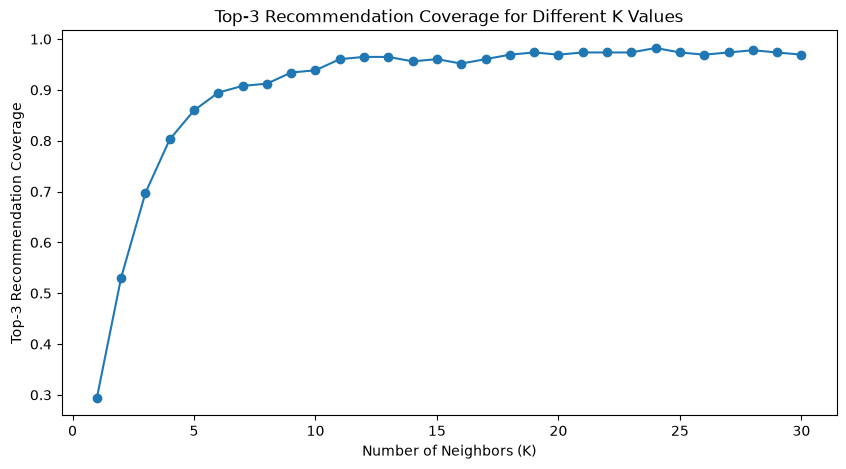

In [32]:
import matplotlib.pyplot as plt

k_values = sorted([k for _, k in top3_validation_results])

coverage_by_k = {
    k: coverage
    for coverage, k in top3_validation_results
}

coverage_values = [
    coverage_by_k[k]
    for k in k_values
]

plt.figure(figsize=(10, 5))
plt.plot(k_values, coverage_values, marker="o")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Top-3 Recommendation Coverage")
plt.title("Top-3 Recommendation Coverage for Different K Values")
plt.show()


## 4. Final Top-3 KNN Recommendation Model

The final model is trained on the full group-aware training set using the K selected from validation.

For this dataset and split, the validation procedure selects **K = 24**.


In [33]:
final_knn = KNeighborsClassifier(
    n_neighbors=24,
    weights="uniform",
    p=2
)

final_knn.fit(X_train, y_train)

print("Final KNN model trained successfully.")


Final KNN model trained successfully.


## 5. Final Top-3 Recommendation Evaluation


In [34]:
final_top3_coverage = top3_coverage(
    final_knn,
    X_test,
    y_test
)

print(
    f"Final Top-3 Recommendation Coverage: "
    f"{final_top3_coverage * 100:.2f}%"
)


Final Top-3 Recommendation Coverage: 99.64%


### Interpretation

The final metric answers:

> **For how many test students did the actual career appear among CareerMatch's three recommendations?**

This is more suitable for career guidance than forcing the model to choose only one exact career, because similar skill and interest profiles can reasonably match multiple career roles.


## 6. Top-3 Career Recommendation Function


In [35]:
def get_top3_recommendations(model, X_input):
    probabilities = model.predict_proba(X_input)[0]

    top3_indices = np.argsort(
        probabilities
    )[-3:][::-1]

    top3_careers = model.classes_[top3_indices]
    top3_scores = probabilities[top3_indices]

    return list(
        zip(top3_careers, top3_scores)
    )


In [36]:
def prepare_student_input(
    education,
    specialization,
    interest,
    skills
):
    # Encode Education Level, Specialization and Interest
    categorical_input = pd.DataFrame({
        "Education_Level": [education],
        "Specialization": [specialization],
        "Interests": [interest]
    })

    categorical_encoded_input = encoder.transform(
        categorical_input
    )

    categorical_input_df = pd.DataFrame(
        categorical_encoded_input,
        columns=encoder.get_feature_names_out(
            categorical_columns
        )
    )

    # Encode multiple selected skills
    skills_encoded_input = skill_encoder.transform(
        [skills]
    )

    skills_input_df = pd.DataFrame(
        skills_encoded_input,
        columns=[
            f"Skill_{skill}"
            for skill in skill_encoder.classes_
        ]
    )

    # Combine all encoded features
    student_encoded = pd.concat(
        [
            categorical_input_df,
            skills_input_df
        ],
        axis=1
    )

    # Match training feature order
    student_encoded = student_encoded.reindex(
        columns=X_encoded.columns,
        fill_value=0
    )

    return student_encoded


## 7. Example Career Recommendation


In [37]:
student = prepare_student_input(
    education="BCA",
    specialization="Computer Applications",
    interest="Technology",
    skills=[
        "Python",
        "Web Development",
        "Databases"
    ]
)

recommendations = get_top3_recommendations(
    final_knn,
    student
)

print("Top 3 Career Recommendations:\n")

for i, (career, score) in enumerate(
    recommendations,
    start=1
):
    print(
        f"{i}. {career} "
        f"- Recommendation Score: {score * 100:.2f}%"
    )


Top 3 Career Recommendations:

1. Web Developer - Recommendation Score: 37.50%
2. System Analyst - Recommendation Score: 33.33%
3. Software Developer - Recommendation Score: 29.17%


### About the Recommendation Score

The recommendation score is the share of the K nearest neighbours voting for each career.

It should be interpreted as a **KNN recommendation score**, not as a guarantee of career success or an absolute probability.


## 8. Optional Experiments

These experiments compare alternative KNN distance metrics and feature-weighting strategies.

They are kept only as supporting analysis and **do not affect the final Top-3 model above**.


In [38]:
# Hamming distance experiment
hamming_results = []

for k in range(1, 31):
    model = KNeighborsClassifier(
        n_neighbors=k,
        metric="hamming",
        algorithm="brute"
    )

    model.fit(X_subtrain, y_subtrain)

    coverage = top3_coverage(
        model,
        X_val,
        y_val
    )

    hamming_results.append((coverage, k))

hamming_results.sort(reverse=True)

print("Best Hamming Top-3 results:")
for coverage, k in hamming_results[:10]:
    print(
        f"Top-3 Coverage: {coverage * 100:.2f}% | K: {k}"
    )


Best Hamming Top-3 results:
Top-3 Coverage: 97.37% | K: 17
Top-3 Coverage: 96.93% | K: 19
Top-3 Coverage: 96.93% | K: 18
Top-3 Coverage: 96.93% | K: 16
Top-3 Coverage: 96.49% | K: 30
Top-3 Coverage: 96.49% | K: 29
Top-3 Coverage: 96.49% | K: 28
Top-3 Coverage: 96.49% | K: 27
Top-3 Coverage: 96.49% | K: 26
Top-3 Coverage: 96.49% | K: 25


In [39]:
# Cosine distance experiment
cosine_results = []

for k in range(1, 31):
    model = KNeighborsClassifier(
        n_neighbors=k,
        metric="cosine",
        algorithm="brute"
    )

    model.fit(X_subtrain, y_subtrain)

    coverage = top3_coverage(
        model,
        X_val,
        y_val
    )

    cosine_results.append((coverage, k))

cosine_results.sort(reverse=True)

print("Best Cosine Top-3 results:")
for coverage, k in cosine_results[:10]:
    print(
        f"Top-3 Coverage: {coverage * 100:.2f}% | K: {k}"
    )


Best Cosine Top-3 results:
Top-3 Coverage: 97.81% | K: 23
Top-3 Coverage: 97.81% | K: 22
Top-3 Coverage: 97.37% | K: 24
Top-3 Coverage: 97.37% | K: 21
Top-3 Coverage: 97.37% | K: 17
Top-3 Coverage: 96.93% | K: 25
Top-3 Coverage: 96.93% | K: 20
Top-3 Coverage: 96.93% | K: 19
Top-3 Coverage: 96.93% | K: 18
Top-3 Coverage: 96.49% | K: 16


In [40]:
# Feature weighting experiment
X_weighted = X_encoded.copy()

for col in X_weighted.columns:
    if col.startswith("Skill_"):
        X_weighted[col] *= 2.5
    elif col.startswith("Specialization_"):
        X_weighted[col] *= 2.0
    elif col.startswith("Interests_"):
        X_weighted[col] *= 1.5

print("Weighted feature matrix created.")


Weighted feature matrix created.


In [41]:
train_idx_w, test_idx_w = next(
    gss.split(
        X_weighted,
        y,
        groups=profile_groups
    )
)

X_train_w = X_weighted.iloc[train_idx_w]
X_test_w = X_weighted.iloc[test_idx_w]

y_train_w = y.iloc[train_idx_w]
y_test_w = y.iloc[test_idx_w]

train_groups_w = profile_groups.iloc[train_idx_w]

subtrain_pos_w, val_pos_w = next(
    gss_val.split(
        X_train_w,
        y_train_w,
        groups=train_groups_w
    )
)

X_subtrain_w = X_train_w.iloc[subtrain_pos_w]
X_val_w = X_train_w.iloc[val_pos_w]

y_subtrain_w = y_train_w.iloc[subtrain_pos_w]
y_val_w = y_train_w.iloc[val_pos_w]


In [42]:
weighted_results = []

for k in range(1, 31):
    model = KNeighborsClassifier(
        n_neighbors=k,
        weights="uniform",
        p=2
    )

    model.fit(
        X_subtrain_w,
        y_subtrain_w
    )

    coverage = top3_coverage(
        model,
        X_val_w,
        y_val_w
    )

    weighted_results.append(
        (coverage, k)
    )

weighted_results.sort(reverse=True)

print("Best Weighted-Feature Top-3 results:")
for coverage, k in weighted_results[:10]:
    print(
        f"Top-3 Coverage: {coverage * 100:.2f}% | K: {k}"
    )


Best Weighted-Feature Top-3 results:
Top-3 Coverage: 95.18% | K: 10
Top-3 Coverage: 94.74% | K: 15
Top-3 Coverage: 94.74% | K: 12
Top-3 Coverage: 94.74% | K: 11
Top-3 Coverage: 94.30% | K: 16
Top-3 Coverage: 94.30% | K: 13
Top-3 Coverage: 93.86% | K: 14
Top-3 Coverage: 93.42% | K: 17
Top-3 Coverage: 92.98% | K: 9
Top-3 Coverage: 92.11% | K: 8


In [43]:
import joblib

joblib.dump(final_knn, "../model/final_knn.pkl")
joblib.dump(encoder, "../model/encoder.pkl")
joblib.dump(skill_encoder, "../model/skill_encoder.pkl")
joblib.dump(list(X_encoded.columns), "../model/feature_columns.pkl")

print("Model and encoders saved successfully.")

Model and encoders saved successfully.
